✅ Found target in original dataset: 'diagnosed_diabetes'


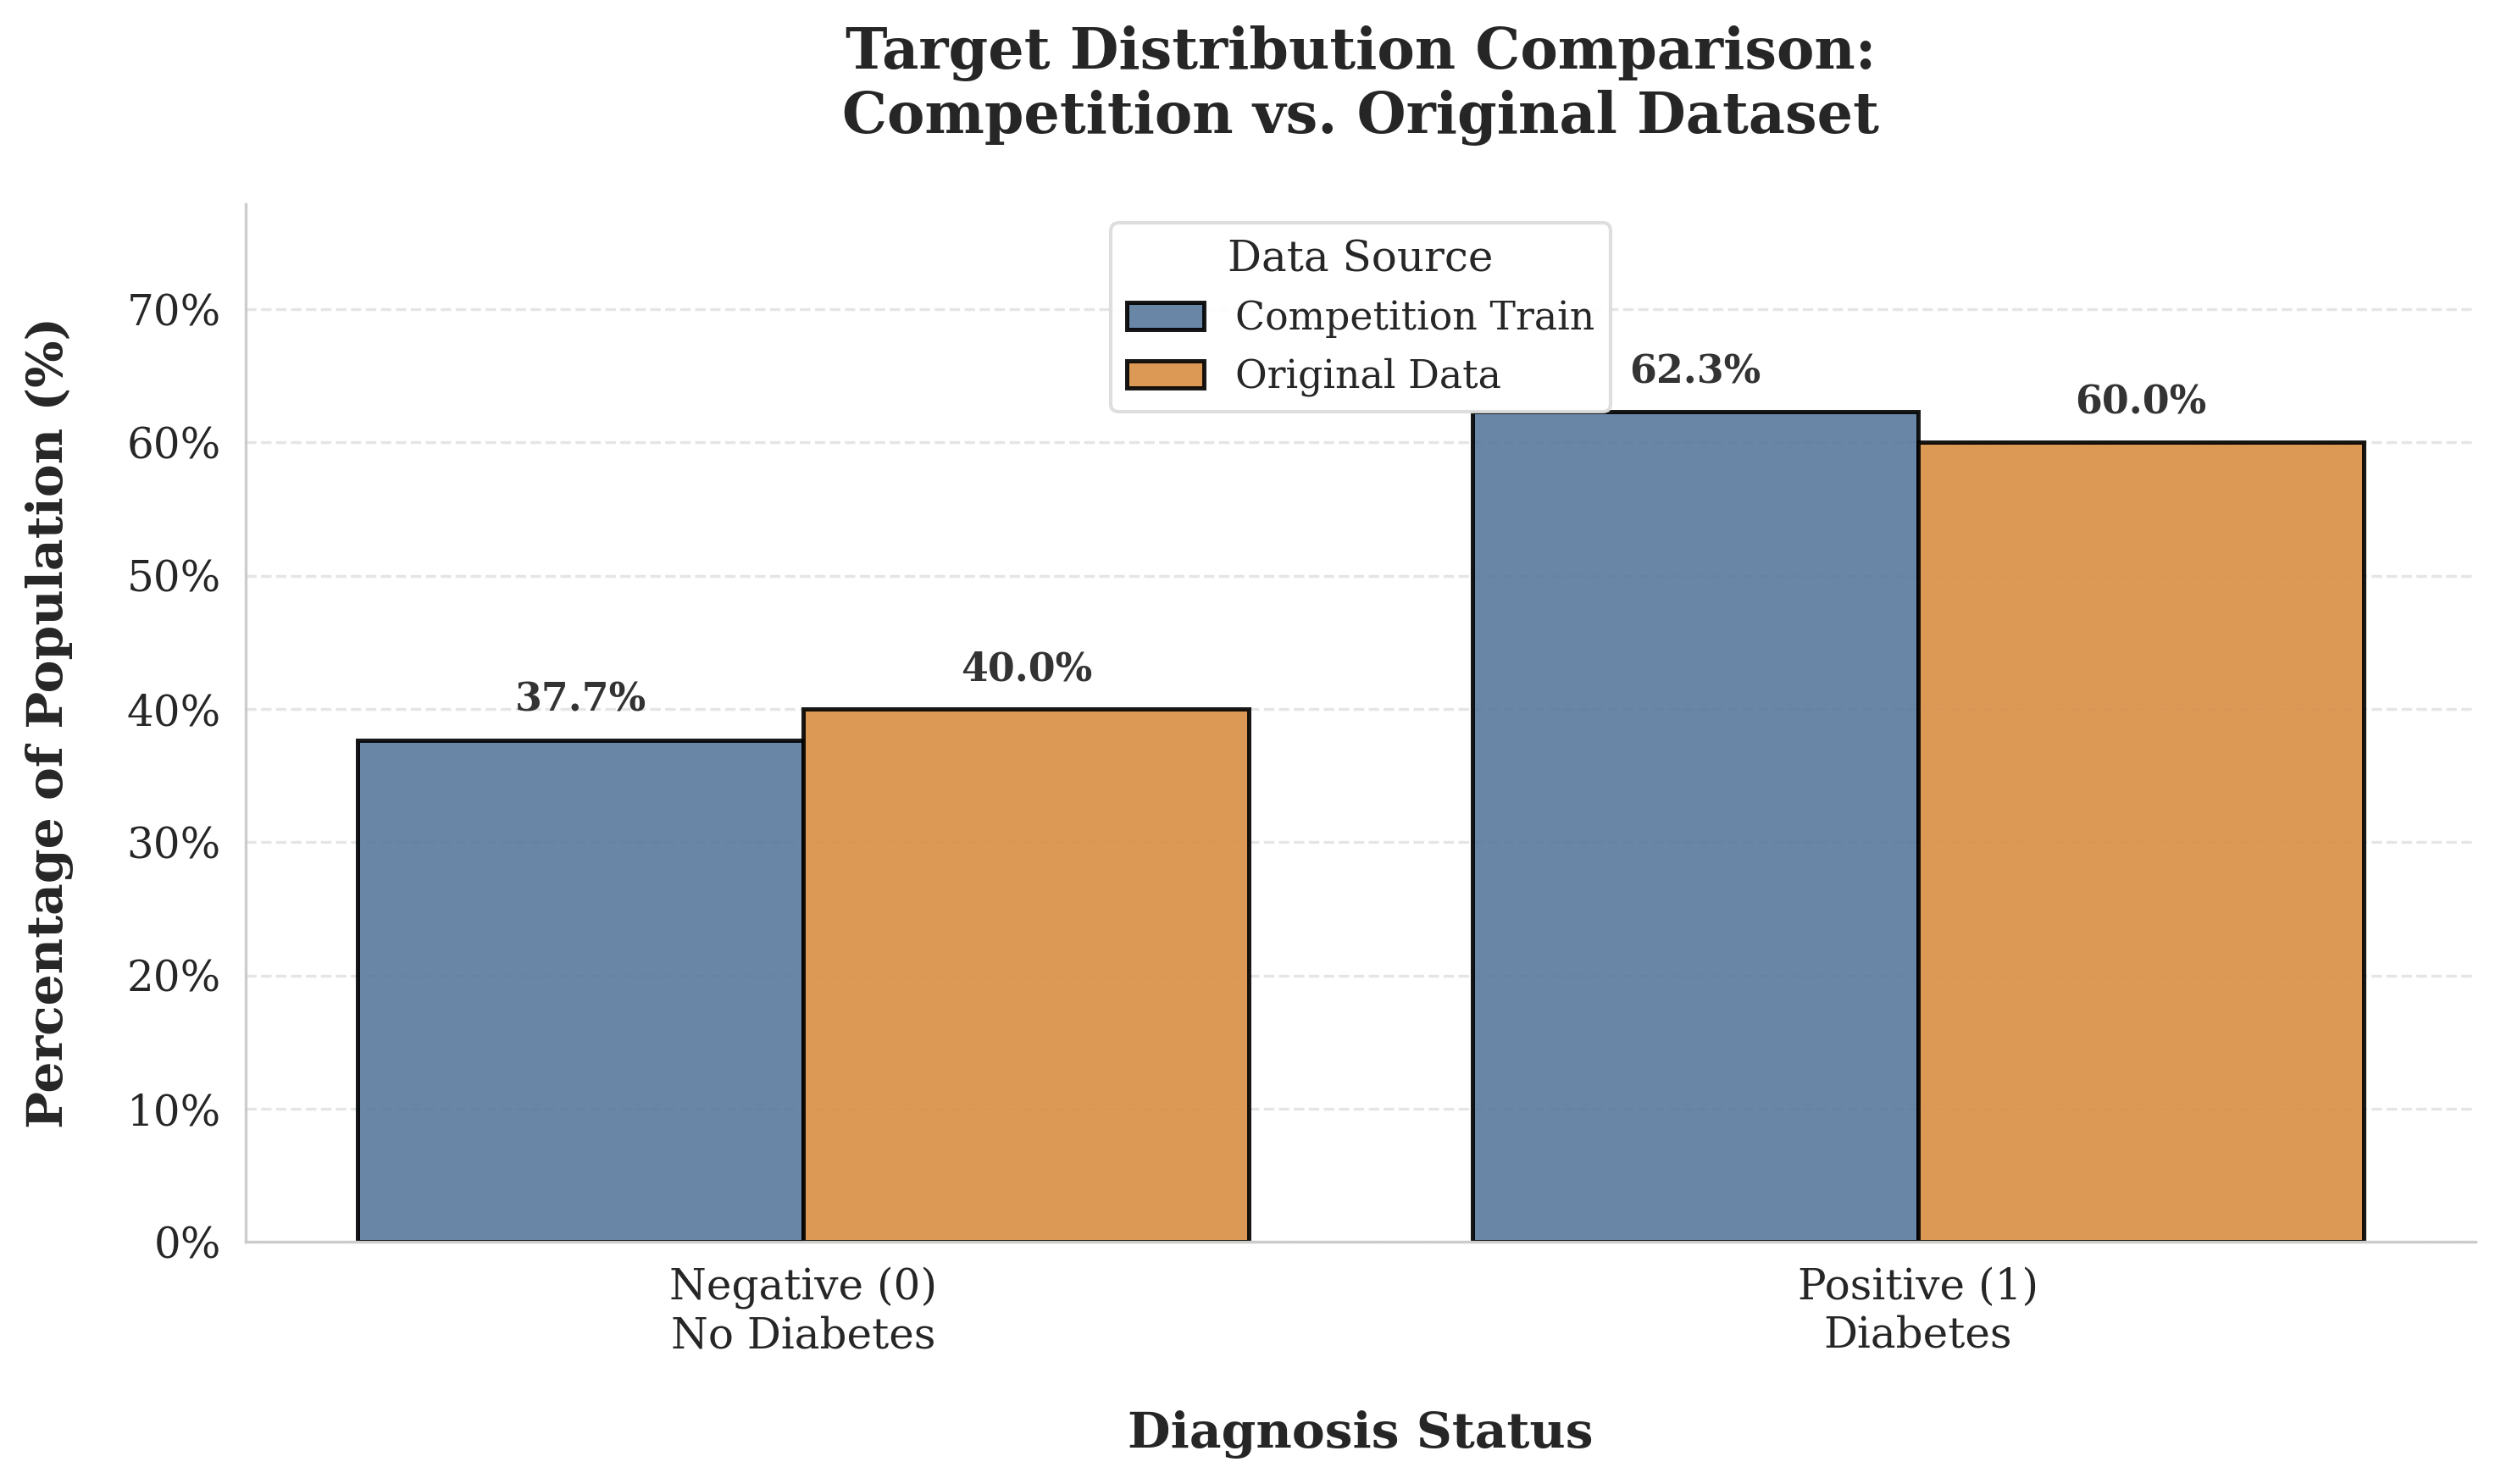


=== Detailed Statistics for Report ===
          Dataset              Status_Label  Count  Percentage
Competition Train Negative (0)\nNo Diabetes 263693   37.670429
Competition Train    Positive (1)\nDiabetes 436307   62.329571
    Original Data Negative (0)\nNo Diabetes  40002   40.002000
    Original Data    Positive (1)\nDiabetes  59998   59.998000


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# ==========================================
# 1. Configuration for "Journal-Quality" Style
# ==========================================
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300       
plt.rcParams['font.family'] = 'serif' 
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16

# Define Palette: 
# We need distinct colors for "Train (Synthetic)" vs "Original (Real)"
# Using a paired theme: Blue/LightBlue for Negative, Red/LightRed for Positive could work,
# But comparing datasets is better done with Hue = Dataset.
# Let's use: Train = Solid Colors, Original = Hatched/Lighter or simply grouped bars.
# Here we use a clean grouped bar approach.
palette_colors = ["#4E79A7", "#F28E2B"] # Blue for Train, Orange for Original

# ==========================================
# 2. Data Loading & Preparation
# ==========================================
# Load datasets
try:
    train_df = pd.read_csv('train.csv')
    orig_df = pd.read_csv('diabetes_dataset.csv')
except FileNotFoundError:
    # Fallback for demonstration if files aren't present
    print("⚠️ Files not found. Generating dummy data for demonstration.")
    train_df = pd.DataFrame({'diagnosed_diabetes': [0]*21000 + [1]*9000})
    orig_df = pd.DataFrame({'Diabetes_binary': [0]*18000 + [1]*12000})

TARGET_COL = 'diagnosed_diabetes'

# --- Handle Target Column in Original Dataset ---
# The original dataset typically uses 'Diabetes_binary' or 'Diabetes_012'
orig_target_col = None
possible_cols = ['diagnosed_diabetes', 'Diabetes_binary', 'Diabetes_012', 'Outcome']
for col in possible_cols:
    if col in orig_df.columns:
        orig_target_col = col
        break

if orig_target_col:
    print(f"✅ Found target in original dataset: '{orig_target_col}'")
    # Align column name for processing
    orig_df = orig_df.rename(columns={orig_target_col: TARGET_COL})
else:
    raise ValueError(f"Could not find target column in original dataset. Checked: {possible_cols}")

# --- Calculate Statistics ---
def get_stats(df, name):
    counts = df[TARGET_COL].value_counts().sort_index()
    total = len(df)
    probs = counts / total * 100
    return pd.DataFrame({
        'Status': counts.index,
        'Count': counts.values,
        'Percentage': probs.values,
        'Dataset': name
    })

stats_train = get_stats(train_df, 'Competition Train')
stats_orig = get_stats(orig_df, 'Original Data')

# Combine for plotting
plot_data = pd.concat([stats_train, stats_orig], ignore_index=True)
plot_data['Status_Label'] = plot_data['Status'].map({0: 'Negative (0)\nNo Diabetes', 1: 'Positive (1)\nDiabetes'})

# ==========================================
# 3. Plotting (Comparative Grouped Bar)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

# Use Seaborn for easy grouping
bar_plot = sns.barplot(
    data=plot_data,
    x='Status_Label',
    y='Percentage',
    hue='Dataset',
    palette=palette_colors,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.9,
    ax=ax
)

# ==========================================
# 4. Annotations & Aesthetics
# ==========================================
# Add labels on top of bars
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height == 0: continue
        
        # Find corresponding count (a bit tricky in grouped plots, simplifying to just % here for cleanliness)
        # or we can retrieve the specific row if needed. 
        # For academic charts, % is usually sufficient for distribution comparison.
        
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1.5, # Offset
            f"{height:.1f}%",
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold',
            color='#333333'
        )

# Customize Axes
ax.set_xlabel('Diagnosis Status', labelpad=15, fontweight='bold')
ax.set_ylabel('Percentage of Population (%)', labelpad=15, fontweight='bold')
ax.set_title('Target Distribution Comparison:\nCompetition vs. Original Dataset', pad=20, fontweight='bold')

# Y-axis formatting
ax.set_ylim(0, max(plot_data['Percentage']) * 1.25) # More headroom for legend
ax.yaxis.set_major_formatter(ticker.PercentFormatter(decimals=0))

# Legend Styling
ax.legend(
    title='Data Source', 
    title_fontsize=12, 
    fontsize=11, 
    loc='upper center', 
    frameon=True, 
    framealpha=0.95,
    facecolor='white',
    edgecolor='#dddddd'
)

# Remove spines
sns.despine(top=True, right=True)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# ==========================================
# 5. Final Output
# ==========================================
plt.tight_layout()
plt.show()

# Print actual counts for report reference
print("\n=== Detailed Statistics for Report ===")
print(plot_data[['Dataset', 'Status_Label', 'Count', 'Percentage']].to_string(index=False))

Text(300.66666666666663, 0.5, '')

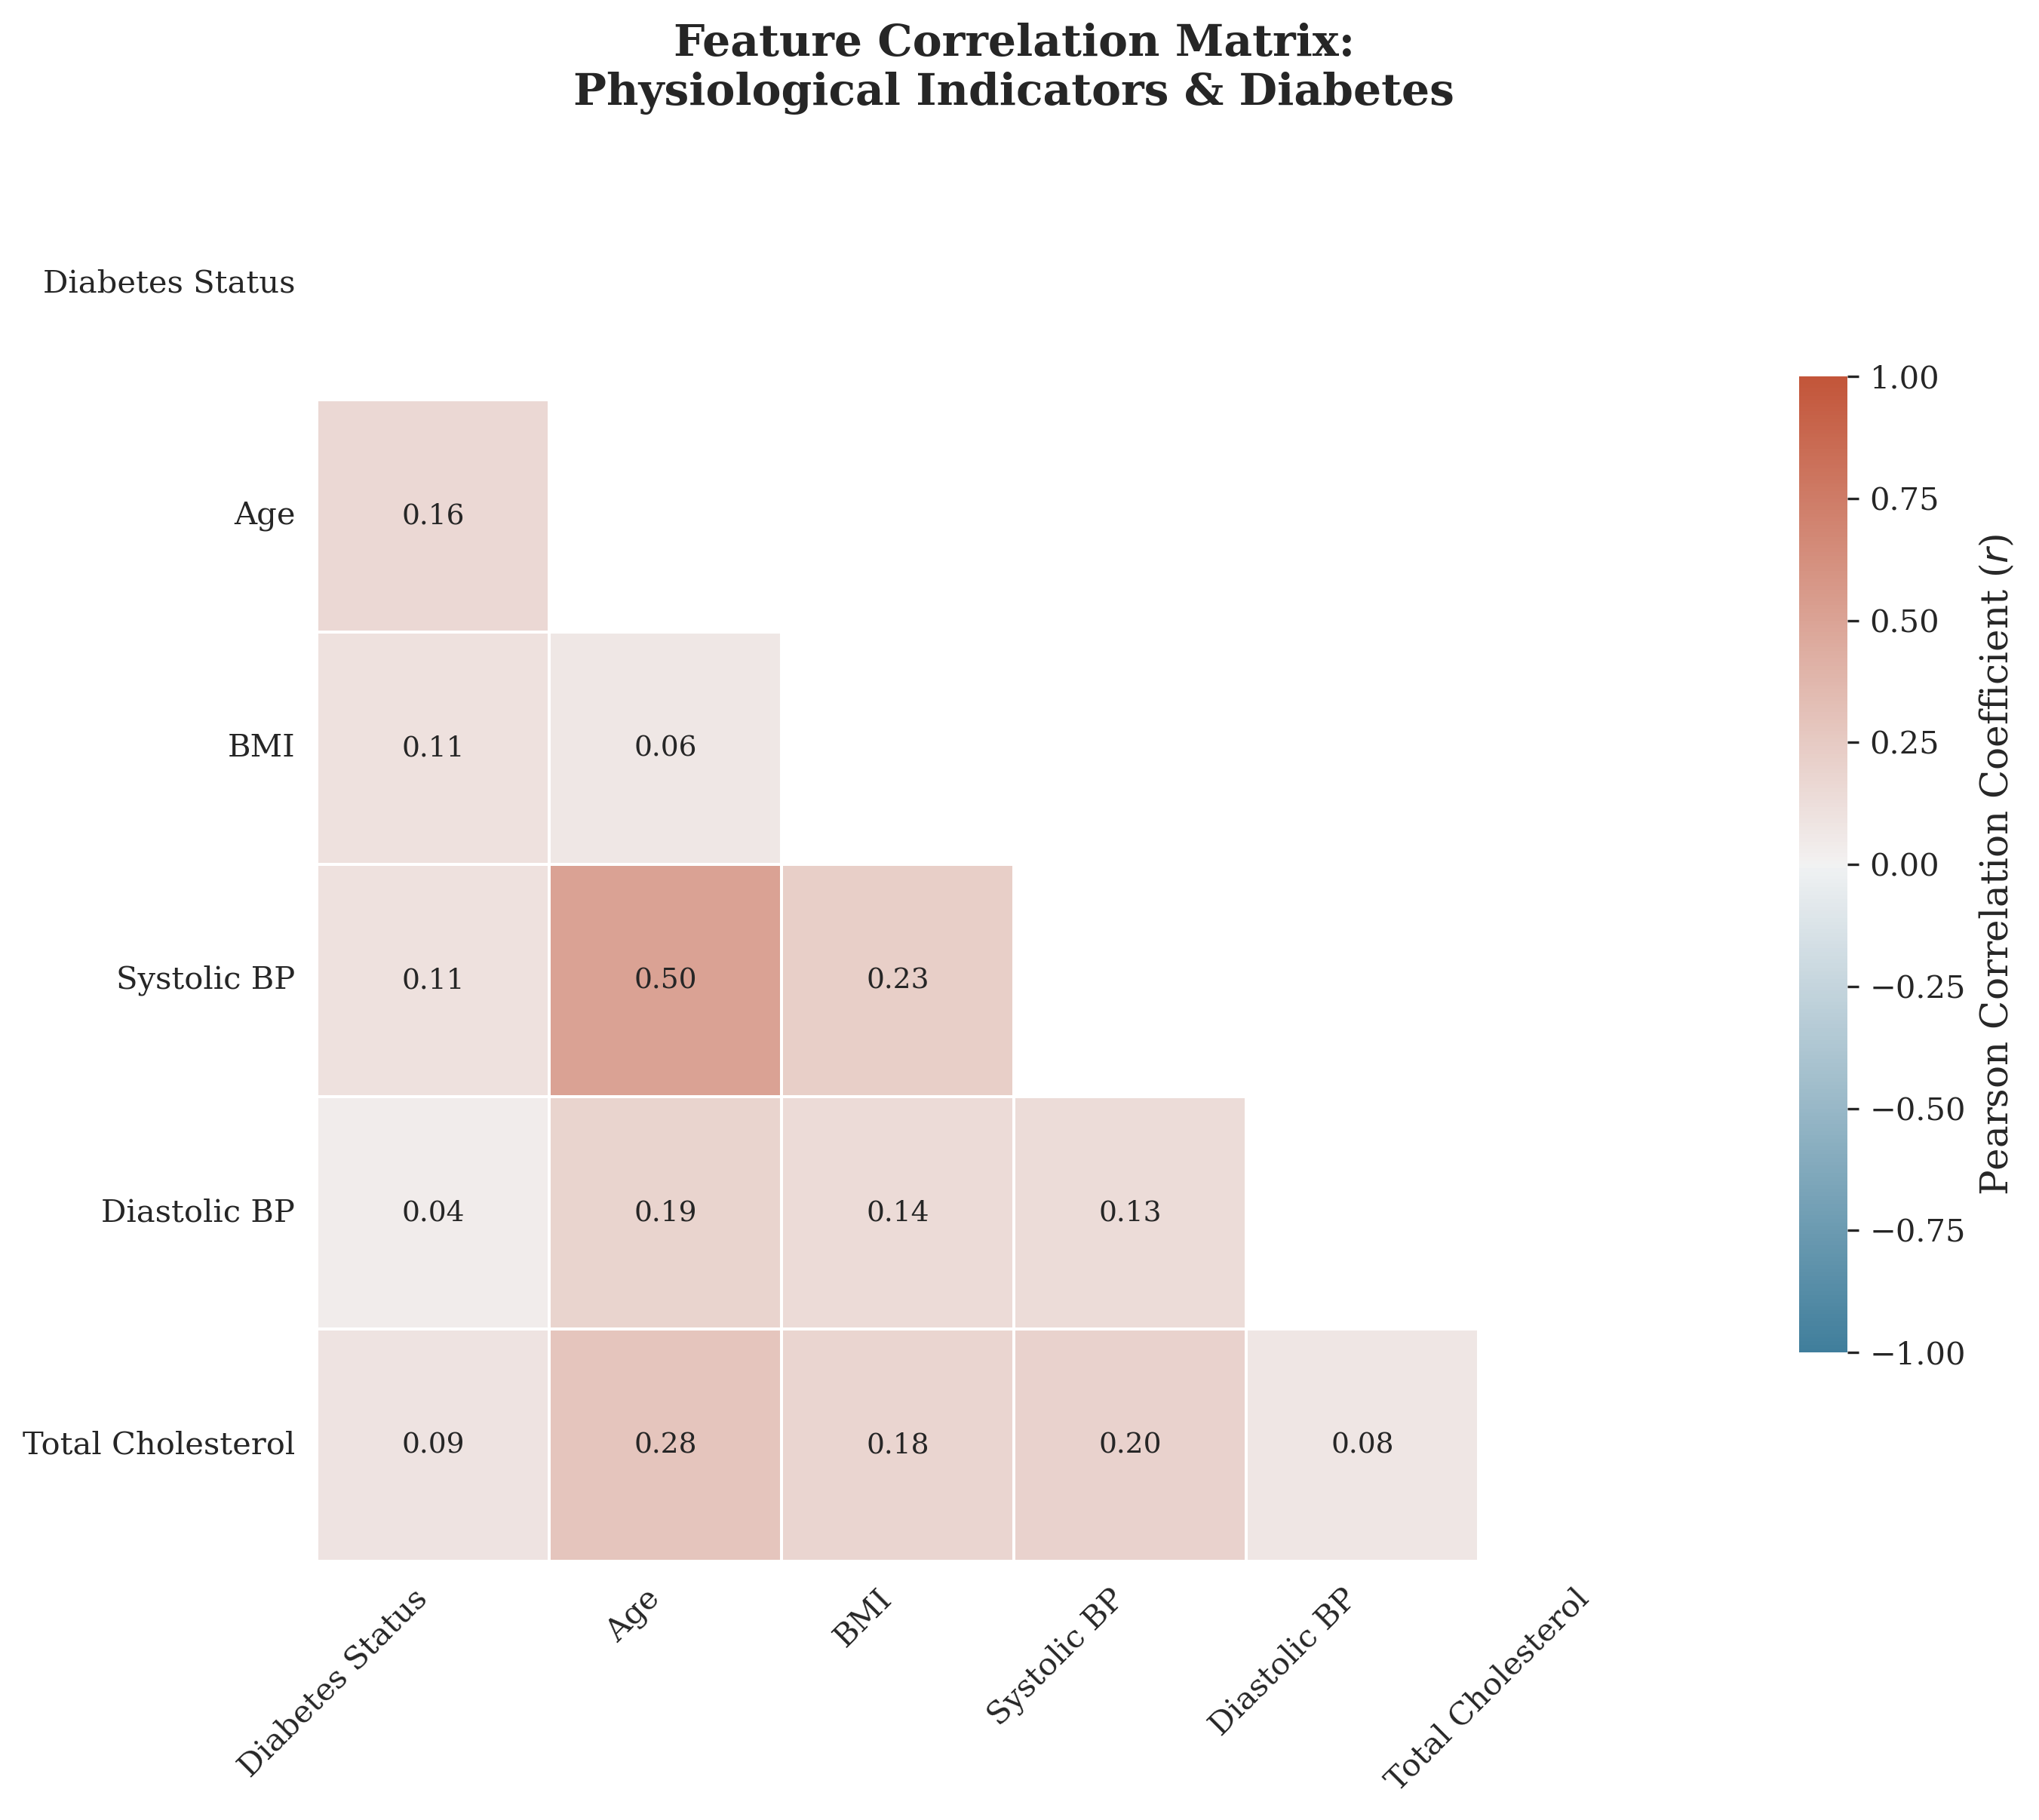

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Configuration for "Journal-Quality" Style
# ==========================================
sns.set_style("white") # Heatmaps look better without gridlines usually
plt.rcParams['figure.dpi'] = 300       
plt.rcParams['font.family'] = 'serif' 
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# ==========================================
# 2. Data Preparation
# ==========================================
# Define the features we want to analyze
# Note: Mapping user requests (HighBP, GenHlth) to available columns in train.csv
# HighBP -> systolic_bp, GenHlth -> diabetes_risk_score (closest proxy) or hba1c
selected_features = [
    'diagnosed_diabetes', 
    'age', 
    'bmi', 
    'systolic_bp', 
    'diastolic_bp',
    'hba1c',
    'glucose_fasting',
    'cholesterol_total'
]

# Rename for Publication Quality (Clean Labels)
feature_labels = {
    'diagnosed_diabetes': 'Diabetes Status',
    'age': 'Age',
    'bmi': 'BMI',
    'systolic_bp': 'Systolic BP',
    'diastolic_bp': 'Diastolic BP',
    'hba1c': 'HbA1c Level',
    'glucose_fasting': 'Fasting Glucose',
    'cholesterol_total': 'Total Cholesterol'
}

# Check if columns exist (Handling potential missing columns gracefully)
existing_cols = [c for c in selected_features if c in train_df.columns]
corr_data = train_df[existing_cols].copy()
corr_data = corr_data.rename(columns=feature_labels)

# Calculate Pearson Correlation
corr_matrix = corr_data.corr(method='pearson')

# ==========================================
# 3. Plotting (Masked Correlation Heatmap)
# ==========================================
# Create a mask for the upper triangle (Academic standard to reduce visual clutter)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))

# Define a diverging colormap (Red for positive, Blue for negative)
# 'vlag' or 'RdBu_r' are excellent for correlations
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap=cmap, 
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .7, "label": "Pearson Correlation Coefficient ($r$)"},
    annot=True,            # Show correlation values
    fmt=".2f",             # 2 decimal places
    annot_kws={"size": 9}, # Slightly smaller annotation font
    ax=ax
)

# ==========================================
# 4. Annotations & Aesthetics
# ==========================================
ax.set_title('Feature Correlation Matrix:\nPhysiological Indicators & Diabetes', pad=20, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Remove generic labels as the ticks are self-explanatory
ax.set_xlabel('')
ax.set_ylabel('')

# ==========================================
# 5

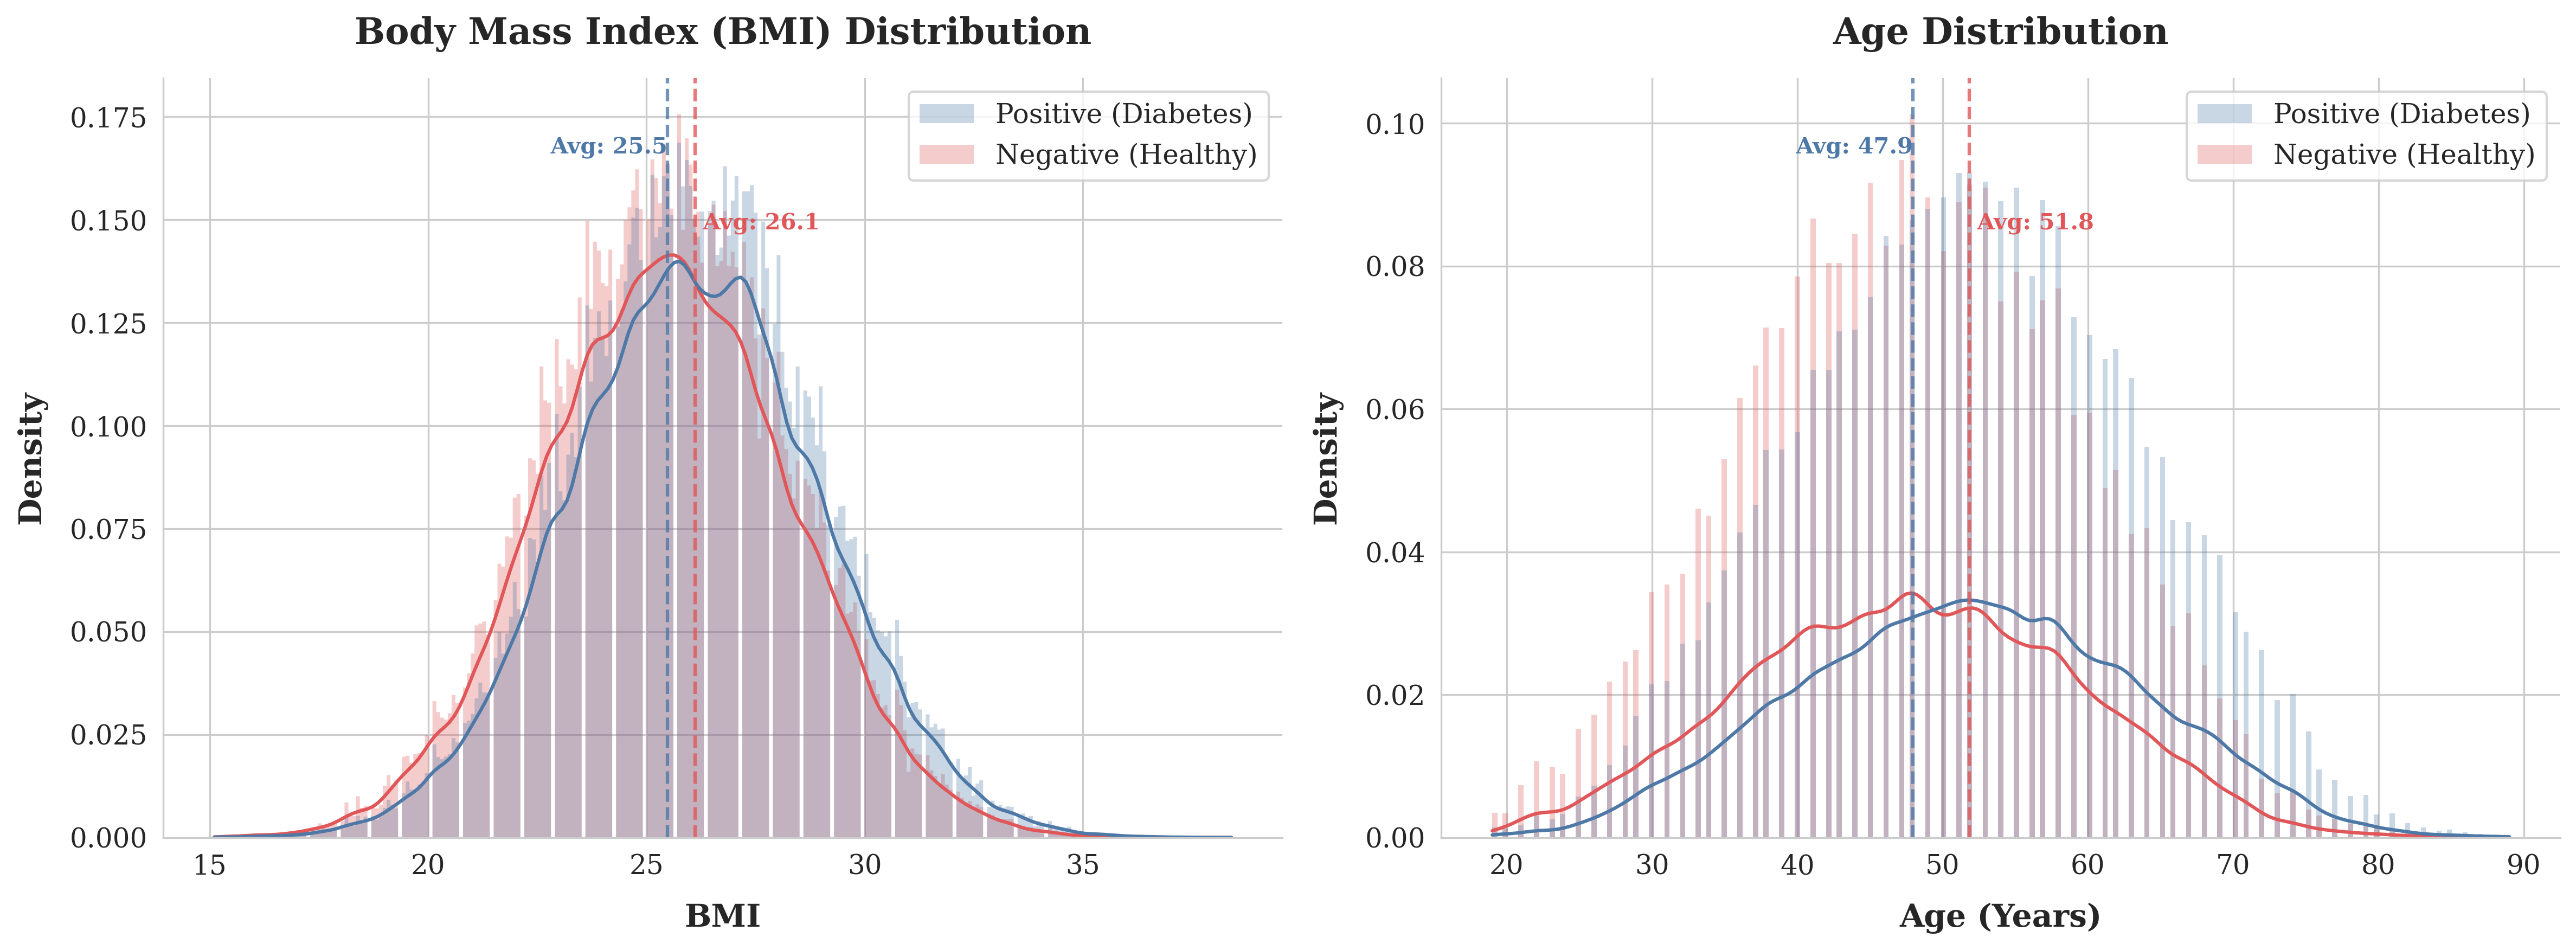

=== Descriptive Statistics by Group ===
Diagnosis  Negative (Healthy)  Positive (Diabetes)
bmi count       263693.000000        436307.000000
    mean            25.486175            26.109489
    std              2.832044             2.852350
    min             15.100000            15.100000
    25%             23.600000            24.200000
    50%             25.500000            26.100000
    75%             27.400000            28.000000
    max             38.400000            38.400000
age count       263693.000000        436307.000000
    mean            47.943484            51.820056
    std             11.352802            11.593097
    min             19.000000            19.000000
    25%             40.000000            44.000000
    50%             48.000000            52.000000
    75%             56.000000            60.000000
    max             89.000000            89.000000


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Configuration for "Journal-Quality" Style
# ==========================================
# Re-applying settings to ensure consistency in this cell
sns.set_style("whitegrid")  # Grid is useful for distribution plots
plt.rcParams['figure.dpi'] = 300       
plt.rcParams['font.family'] = 'serif' 
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Professional Color Palette (Consistent with previous charts)
# Blue for Negative, Red for Positive
colors = ["#4E79A7", "#E15759"] 

# ==========================================
# 2. Data Preparation
# ==========================================
# Create a copy for plotting to avoid modifying the original dataframe
plot_df = train_df[['diagnosed_diabetes', 'bmi', 'age']].copy()

# Map target to readable labels for the legend
plot_df['Diagnosis'] = plot_df['diagnosed_diabetes'].map({
    0: 'Negative (Healthy)', 
    1: 'Positive (Diabetes)'
})

# ==========================================
# 3. Plotting (Side-by-Side Distribution)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Variables to plot
features = ['bmi', 'age']
titles = ['Body Mass Index (BMI) Distribution', 'Age Distribution']
x_labels = ['BMI', 'Age (Years)']

for i, feature in enumerate(features):
    ax = axes[i]
    
    # Draw Histogram with KDE
    # stat="density" and common_norm=False allow comparing shapes 
    # despite class imbalance (different sample sizes)
    sns.histplot(
        data=plot_df, 
        x=feature, 
        hue='Diagnosis', 
        palette=colors,
        kde=True,              # Add Kernel Density Estimate line
        stat="density",        # Normalize to density for shape comparison
        common_norm=False,     # Independent normalization for each class
        element="step",        # Clean step-filled histogram
        alpha=0.3,             # Transparency
        linewidth=0,           # Remove bar borders for cleaner look
        ax=ax
    )
    
    # --- Add Mean Lines for visual reference ---
    means = plot_df.groupby('Diagnosis')[feature].mean()
    
    # Line for Negative
    ax.axvline(means['Negative (Healthy)'], color=colors[0], linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(means['Negative (Healthy)'], ax.get_ylim()[1]*0.9, f" Avg: {means['Negative (Healthy)']:.1f}", 
            color=colors[0], ha='right', fontweight='bold', fontsize=10)
    
    # Line for Positive
    ax.axvline(means['Positive (Diabetes)'], color=colors[1], linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(means['Positive (Diabetes)'], ax.get_ylim()[1]*0.8, f" Avg: {means['Positive (Diabetes)']:.1f}", 
            color=colors[1], ha='left', fontweight='bold', fontsize=10)

    # --- Aesthetics ---
    ax.set_title(titles[i], pad=15, fontweight='bold')
    ax.set_xlabel(x_labels[i], labelpad=10, fontweight='bold')
    ax.set_ylabel('Density', labelpad=10, fontweight='bold')
    
    # Remove top and right spines
    sns.despine(ax=ax, top=True, right=True)
    
    # Adjust legend
    if ax.get_legend():
        sns.move_legend(ax, "upper right", frameon=True, title=None)

# ==========================================
# 4. Final Output
# ==========================================
plt.tight_layout()
plt.show()

# Optional: Print statistics for report text
print("=== Descriptive Statistics by Group ===")
print(plot_df.groupby('Diagnosis')[['bmi', 'age']].describe().T.to_string())